In [9]:
import os
from pathlib import Path
import sys
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(r"E:\Computer Graphics\SorghumData\524042_33.08_-111.97_2021.csv", skiprows=2)

In [8]:
df.head()

,Year,Month,Day,Hour,Minute,DHI,DNI,GHI,Clearsky DHI,Clearsky DNI,...,Dew Point,Solar Zenith Angle,Fill Flag,Surface Albedo,Wind Speed,Precipitable Water,Wind Direction,Relative Humidity,Temperature,Pressure
0,2021,1,1,0,0,0,0,0,0,0,...,-10.1,167.75,0,0.24,1.1,0.9,28,26.81,7.9,968
1,2021,1,1,0,5,0,0,0,0,0,...,-10.1,168.34,0,0.24,1.0,0.9,28,26.81,7.9,968
2,2021,1,1,0,10,0,0,0,0,0,...,-10.1,168.85,0,0.24,1.0,0.9,29,26.99,7.8,968
3,2021,1,1,0,15,0,0,0,0,0,...,-10.1,169.26,0,0.24,1.0,0.9,29,26.99,7.8,968
4,2021,1,1,0,20,0,0,0,0,0,...,-10.1,169.58,0,0.24,1.0,0.9,30,26.99,7.8,968


In [13]:
df[["Year","Month", "Day", "Hour", "Minute", "Solar Zenith Angle"]]

,Year,Month,Day,Hour,Minute,Solar Zenith Angle
0,2021,1,1,0,0,167.75
1,2021,1,1,0,5,168.34
2,2021,1,1,0,10,168.85
3,2021,1,1,0,15,169.26
4,2021,1,1,0,20,169.58
...,...,...,...,...,...,...
105115,2021,12,31,23,35,163.99
105116,2021,12,31,23,40,164.83
105117,2021,12,31,23,45,165.63
105118,2021,12,31,23,50,166.39


In [20]:
df['ts'] = pd.to_datetime(df[['Year','Month','Day','Hour','Minute']])


mask = (df['ts'] >= '2021-07-07') & (df['ts'] < '2021-07-10')
sub = df.loc[mask].copy()
sub[["Year","Month", "Day", "Hour", "Minute", "Solar Zenith Angle"]]
sub['datetime'] = pd.to_datetime(sub[['Year','Month','Day','Hour','Minute']])
two_cols = pd.DataFrame({
    'datetime': sub['datetime'],
    'sun_direction': sub["Solar Zenith Angle"]
})
two_cols

,datetime,sun_direction
53856,2021-07-07 00:00:00,123.82
53857,2021-07-07 00:05:00,123.98
53858,2021-07-07 00:10:00,124.11
53859,2021-07-07 00:15:00,124.21
53860,2021-07-07 00:20:00,124.29
...,...,...
54715,2021-07-09 23:35:00,123.01
54716,2021-07-09 23:40:00,123.28
54717,2021-07-09 23:45:00,123.54
54718,2021-07-09 23:50:00,123.77


### Load the original PAR results


In [ ]:
df = pd.read_csv(r"D:\zhan5455\SorghumData\CR300Series_A_Table1_071621_pos_Y.csv", skiprows=1)

df.head()

C:\Users\zhan5455\AppData\Local\Temp\ipykernel_53244\4018813461.py:1: DtypeWarning: Columns (1,2,3,5,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\zhan5455\SorghumData\CR300Series_A_Table1_071621_pos_Y.csv", skiprows=1)


,TIMESTAMP,RECORD,BattV,PTemp_C,DiffVolt_A1,DiffVolt_A2,DiffVolt_A3,PAR_A1,PAR_A2,PAR_A3
0,TS,RN,Volts,Deg C,mV,mV,mV,NaN,NaN,NaN
1,NaN,NaN,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp
2,2021-07-15 10:04:08,0,13.55,30.41,9.64,27.27,43.01,412.2,1034,1784
3,2021-07-15 10:04:09,1,13.55,30.42,9.94,27.3,42.99,424,1036,1783
4,2021-07-15 10:04:10,2,13.55,30.43,9.91,27.82,42.98,423.1,1058,1783


In [23]:
df = df.iloc[2:].reset_index(drop=True)

cols = ["PAR_A1","PAR_A2","PAR_A3"]
for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce') 

par = df[cols].to_numpy(dtype=float)

rn = np.arange(0, par.shape[0])
rn

array([     0,      1,      2, ..., 102107, 102108, 102109],
      shape=(102110,))

In [24]:
print(par.dtype)
print(par[:10])

float64
[[ 412.2 1034.  1784. ]
 [ 424.  1036.  1783. ]
 [ 423.1 1058.  1783. ]
 [ 420.8 1021.  1783. ]
 [ 422.3 1039.  1782. ]
 [ 422.9 1032.  1782. ]
 [ 410.5 1044.  1781. ]
 [ 428.  1023.  1781. ]
 [ 415.8 1053.  1782. ]
 [ 422.5 1040.  1781. ]]


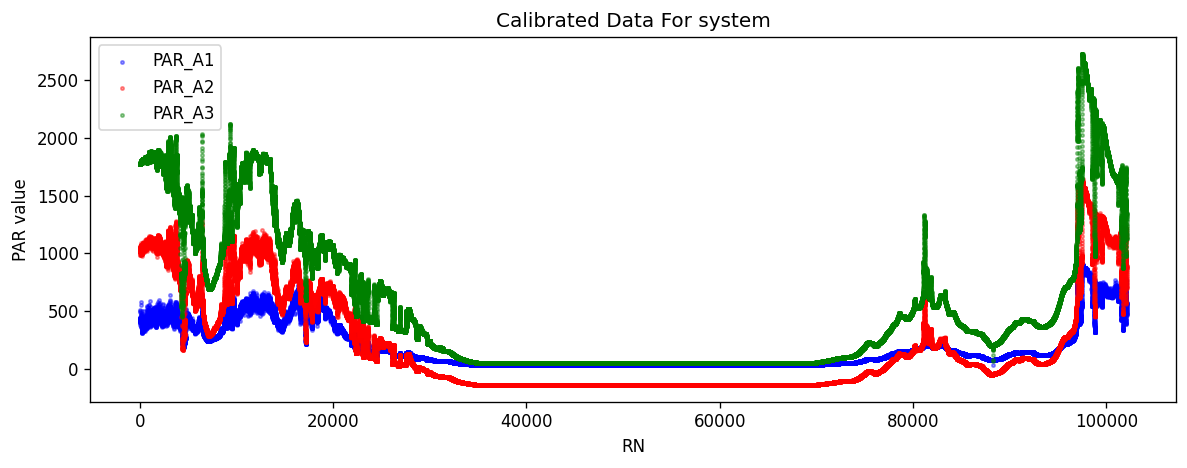

In [ ]:
fig, ax = plt.subplots(figsize=(10,4), dpi=120)
ax.scatter(rn, par[:,0], color='b', s=4, alpha=0.4, label='PAR_A1')
ax.scatter(rn, par[:,1], color='r', s=4, alpha=0.4, label='PAR_A2')
ax.scatter(rn, par[:,2], color='g', s=4, alpha=0.4, label='PAR_A3')
ax.set_xlabel('Record Number')
ax.set_ylabel('PAR value')
ax.set_title('Calibrated Data For system')
ax.legend()
fig.tight_layout()
plt.show()

In [54]:
illumination_results = np.load(r"D:\zhan5455\SorghumIlluminationEstimationResults\results.npy")
time = np.load(r"D:\zhan5455\SorghumIlluminationEstimationResults\timestamps.npy")
sun_direcitons = np.load(r"D:\zhan5455\SorghumIlluminationEstimationResults\sun_directions.npy")

In [55]:
illumination_results.shape

(576, 588, 3, 3)

In [56]:
positions = illumination_results[0, :, 0, :] 
y_vals = positions[:, 1]   
unique_y = np.unique(y_vals)

groups = {}

for y in unique_y:
    idx = np.where(np.isclose(y_vals, y))[0]
    groups[y] = idx

sorted_heights = np.sort(unique_y)
group_low    = groups[sorted_heights[0]]
group_mid    = groups[sorted_heights[1]]
group_high   = groups[sorted_heights[2]]

data_low  = illumination_results[:, group_low,  :, :] 
data_mid  = illumination_results[:, group_mid,  :, :]
data_high = illumination_results[:, group_high, :, :]


In [57]:
flux = illumination_results[:,:,1]
flux_len = np.linalg.norm(flux, axis=-1)
flux_len.shape

(576, 588)

In [58]:
flux_low_average = flux_len[:, group_low].mean(-1)
flux_low_average.shape
flux_mid_average = flux_len[:, group_mid].mean(-1)
flux_mid_average.shape
flux_high_average = flux_len[:, group_high].mean(-1)
print(flux_high_average.shape)

(576,)


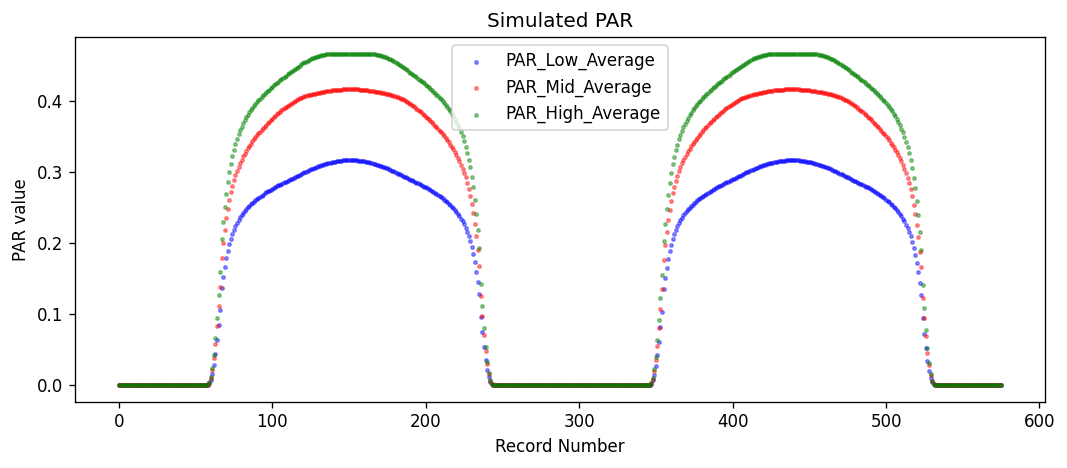

In [62]:
rn = np.arange(time.shape[0])

fig, ax = plt.subplots(figsize=(9,4), dpi=120)
ax.scatter(rn, flux_low_average, color='b', s=4, alpha=0.4, label='PAR_Low_Average')
ax.scatter(rn, flux_mid_average, color='r', s=4, alpha=0.4, label='PAR_Mid_Average')
ax.scatter(rn, flux_high_average, color='g', s=4, alpha=0.4, label='PAR_High_Average')
ax.set_xlabel('Record Number')
ax.set_ylabel('PAR value')
ax.set_title('Simulated PAR')
ax.legend()
fig.tight_layout()
plt.show()